In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Set Datalist

In [2]:
file_path = r'C:\Users\sharif\Desktop\6.9-Final_AllReactive.xlsx'
df = pd.read_excel(file_path)
df.head()

,"STREAMS(""ETHANOL"").T","STREAMS(""P-ACID"").T","STREAMS(""S15"").T","STREAMS(""C1-INPUT"").T","STREAMS(""S26"").T","STREAMS(""S28"").T","STREAMS(""ETHANOL"").P","STREAMS(""P-ACID"").P","STREAMS(""S15"").P","STREAMS(""C1-INPUT"").P",...,"BLOCKS(""C1"").Stage(29).T","BLOCKS(""C1"").Stage(30).T","BLOCKS(""C1"").Stage(31).T","BLOCKS(""C1"").Stage(32).T","BLOCKS(""C1"").Stage(33).T","STREAMS(""D1"").Zmn(""ETHYL-01"")","STREAMS(""S29"").Zmn(""ETHYL-01"")","STREAMS(""S8"").Zmn(""ETHYL-01"")","STREAMS(""S29"").F","STREAMS(""D1"").F"
0,25.0,25.0,146.692,139.972,25.4830,25.3346,1.01325,1.01325,1.20551,1.20551,...,141.881,142.038,142.194,142.349,142.584,0.933737,0.999927,0.740045,49.0159,287.386
1,25.0,25.0,146.693,139.972,25.4839,25.3356,1.01325,1.01325,1.20552,1.20552,...,141.883,142.039,142.195,142.351,142.585,0.933735,0.999927,0.740045,49.0159,287.387
2,25.0,25.0,146.693,139.972,25.4844,25.3361,1.01325,1.01325,1.20552,1.20552,...,141.884,142.040,142.196,142.352,142.586,0.933733,0.999927,0.740045,49.0159,287.387
3,25.0,25.0,146.693,139.972,25.4846,25.3363,1.01325,1.01325,1.20552,1.20552,...,141.884,142.041,142.197,142.352,142.586,0.933731,0.999927,0.740045,49.0160,287.387
4,25.0,25.0,146.693,139.972,25.4848,25.3365,1.01325,1.01325,1.20553,1.20553,...,141.885,142.041,142.197,142.352,142.586,0.933730,0.999927,0.740045,49.0160,287.387


In [3]:
df.describe

<bound method NDFrame.describe of        STREAMS("ETHANOL").T  STREAMS("P-ACID").T  STREAMS("S15").T  \
0                      25.0                 25.0           146.692   
1                      25.0                 25.0           146.693   
2                      25.0                 25.0           146.693   
3                      25.0                 25.0           146.693   
4                      25.0                 25.0           146.693   
...                     ...                  ...               ...   
11181                  25.0                 25.0           146.736   
11182                  25.0                 25.0           146.736   
11183                  25.0                 25.0           146.736   
11184                  25.0                 25.0           146.736   
11185                  25.0                 25.0           146.736   

       STREAMS("C1-INPUT").T  STREAMS("S26").T  STREAMS("S28").T  \
0                    139.972           25.4830           

# PreProcessing

In [4]:
x = df.iloc[:, :-5].values
y = df.iloc[:, -5:].values 

In [5]:
scaler_x = StandardScaler()
scaler_y = StandardScaler()
x = scaler_x.fit_transform(x)
y = scaler_y.fit_transform(y)

In [6]:
sequence_length = 10
def create_sequences(x, y, seq_len):
    x_seq, y_seq = [], []
    for i in range(len(x) - seq_len + 1):
        x_seq.append(x[i:i + seq_len])
        y_seq.append(y[i + seq_len - 1])
    return np.array(x_seq), np.array(y_seq)

In [7]:
x_seq, y_seq = create_sequences(x, y, sequence_length)

In [8]:
x_train, x_test, y_train, y_test = train_test_split(x_seq, y_seq, test_size=0.2, random_state=42)

# Model Definition

In [9]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, BatchNormalization, ReLU, Add, Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adam

def tcn_block(inputs, num_filters, kernel_size, dilation_rate, dropout_rate):

    if inputs.shape[-1] != num_filters:
        residual = Conv1D(filters=num_filters, kernel_size=1, padding="same")(inputs)
    else:
        residual = inputs

    x = Conv1D(filters=num_filters, kernel_size=kernel_size, dilation_rate=dilation_rate,
               padding="causal", activation=None)(inputs)
    x = BatchNormalization()(x)
    x = ReLU()(x)
    x = Dropout(rate=dropout_rate)(x)

    x = Conv1D(filters=num_filters, kernel_size=kernel_size, dilation_rate=dilation_rate,
               padding="causal", activation=None)(x)
    x = BatchNormalization()(x)

    x = Add()([residual, x])
    return ReLU()(x)

def build_tcn_model(input_shape, num_filters=64, kernel_size=3, num_blocks=3, dilation_rate=2, dropout_rate=0.2):
   
    inputs = Input(shape=input_shape)
    x = inputs

    for i in range(num_blocks):
        x = tcn_block(x, num_filters=num_filters, kernel_size=kernel_size,
                      dilation_rate=dilation_rate**i, dropout_rate=dropout_rate)
        
    x = Flatten()(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.2)(x)
    outputs = Dense(output_units)(x)

    return Model(inputs=inputs, outputs=outputs)

In [10]:
input_shape = (sequence_length, x_train.shape[2])
output_units = y_train.shape[1]

In [11]:
model = build_tcn_model(input_shape, num_filters=64, kernel_size=3, num_blocks=4, dilation_rate=2, dropout_rate=0.3)
model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 10, 83)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 10, 64)    │     16,000 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 10, 64)    │        256 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 10, 64)    │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 10, 64)    │          0 │ re_lu[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 10, 64)    │     12,352 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 10, 64)    │      5,376 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 10, 64)    │        256 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 10, 64)    │          0 │ conv1d[0][0],     │
│                     │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 10, 64)    │          0 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 10, 64)    │     12,352 │ re_lu_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 10, 64)    │        256 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 10, 64)    │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 10, 64)    │          0 │ re_lu_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 10, 64)    │     12,352 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 10, 64)    │        256 │ conv1d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 10, 64)    │          0 │ re_lu_1[0][0],    │
│                     │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 10, 64)    │          0 │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 10, 64)    │     12,352 │ re_lu_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 10, 64)    │        256 │ conv1d_5[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_4 (ReLU)      │ (None, 10, 64)    │          0 │ batch_normalizat

 Total params: 151,237 (590.77 KB)

 Trainable params: 150,213 (586.77 KB)

 Non-trainable params: 1,024 (4.00 KB)

In [12]:
from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(monitor='val_loss', patience=60, restore_best_weights=True)

In [13]:
history = model.fit(x_train, y_train,
                    validation_data=(x_test, y_test),
                    epochs=100,
                    batch_size=32,
                    callbacks=[early_stopping])

Epoch 1/100
280/280 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 0.8315 - mae: 0.5341 - val_loss: 0.1998 - val_mae: 0.1718
Epoch 2/100
280/280 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.2671 - mae: 0.2753 - val_loss: 0.0515 - val_mae: 0.1311
Epoch 3/100
280/280 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.2182 - mae: 0.2376 - val_loss: 0.0861 - val_mae: 0.1405
Epoch 4/100
280/280 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.1434 - mae: 0.2143 - val_loss: 0.0305 - val_mae: 0.1107
Epoch 5/100
280/280 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.1488 - mae: 0.2060 - val_loss: 0.0193 - val_mae: 0.0920
Epoch 6/100
280/280 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.1167 - mae: 0.1907 - val_loss: 0.0219 - val_mae: 0.0941
Epoch 7/100
280/280 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0937 - mae: 0.1799 - val_loss: 0.0188 - val_mae: 0.0933
Epoch 8/100
280/280 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0965 - mae: 0.1802 - val_loss: 0.0267 - val_mae: 0.0916
Epoch 9/100
280/280 ━━━━━━━━━━━━━━━━━━━

In [14]:
test_loss, test_mae = model.evaluate(x_test, y_test)
print(f"Test Loss: {test_loss}, Test MAE: {test_mae}")

70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0114 - mae: 0.0704
Test Loss: 0.01099554542452097, Test MAE: 0.06918393075466156


In [15]:
y_pred = model.predict(x_test)

70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


In [16]:
mse_list = []
mae_list = []
r2_list = []

In [17]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse = mean_squared_error (y_test , y_pred)
mae = mean_absolute_error (y_test , y_pred)
r2 = r2_score (y_test , y_pred)

mse_list.append(mse)
mae_list.append(mae)
r2_list.append(r2)

In [18]:
mean_mse = np.mean (mse_list)
mean_mae = np.mean (mae_list)
mean_r2 = np.mean (r2_list)

print("Mean Mean Squared Error (MSE) on Training Data :" , mean_mse)
print("Mean Mean Absolute Error (MAE) on Training Data :" , mean_mae)
print("Mean R2 Score on Training Data :" , mean_r2)

Mean Mean Squared Error (MSE) on Training Data : 0.010995548489440735
Mean Mean Absolute Error (MAE) on Training Data : 0.06918393583345403
Mean R2 Score on Training Data : 0.9892573732737187


In [19]:
y_test_original = scaler_y.inverse_transform(y_test.reshape(-1, 5))
y_pred_original = scaler_y.inverse_transform(y_pred.reshape(-1, 5))

In [20]:
import pandas as pd

# اسامی دقیق تارگت‌ها
labels = ['Target1', 'Target2', 'Target3', 'Target4', 'Target5']

# ساخت دیکشنری برای DataFrame
data = {}
for i, label in enumerate(labels):
    data[f'Actual {label}'] = y_test_original[:, i]
    data[f'Predicted {label}'] = y_pred_original[:, i]

# تبدیل به DataFrame
results = pd.DataFrame(data)

# نمایش 20 نمونه اول
print(results.head(5))

   Actual Target1  Predicted Target1  Actual Target2  Predicted Target2  \
0        0.934389           0.934450        0.999927           0.999927   
1        0.934823           0.934701        0.999927           0.999927   
2        0.934790           0.934743        0.999927           0.999927   
3        0.934109           0.934088        0.999927           0.999927   
4        0.931690           0.931891        0.999927           0.999927   

   Actual Target3  Predicted Target3  Actual Target4  Predicted Target4  \
0        0.739812           0.739787         49.5128          49.442005   
1        0.740319           0.740250         49.1687          49.205639   
2        0.741055           0.740884         49.0527          49.030888   
3        0.739055           0.739153         49.1842          49.207176   
4        0.739872           0.739796         48.4612          48.499454   

   Actual Target5  Predicted Target5  
0         288.918         288.941742  
1         288.760   

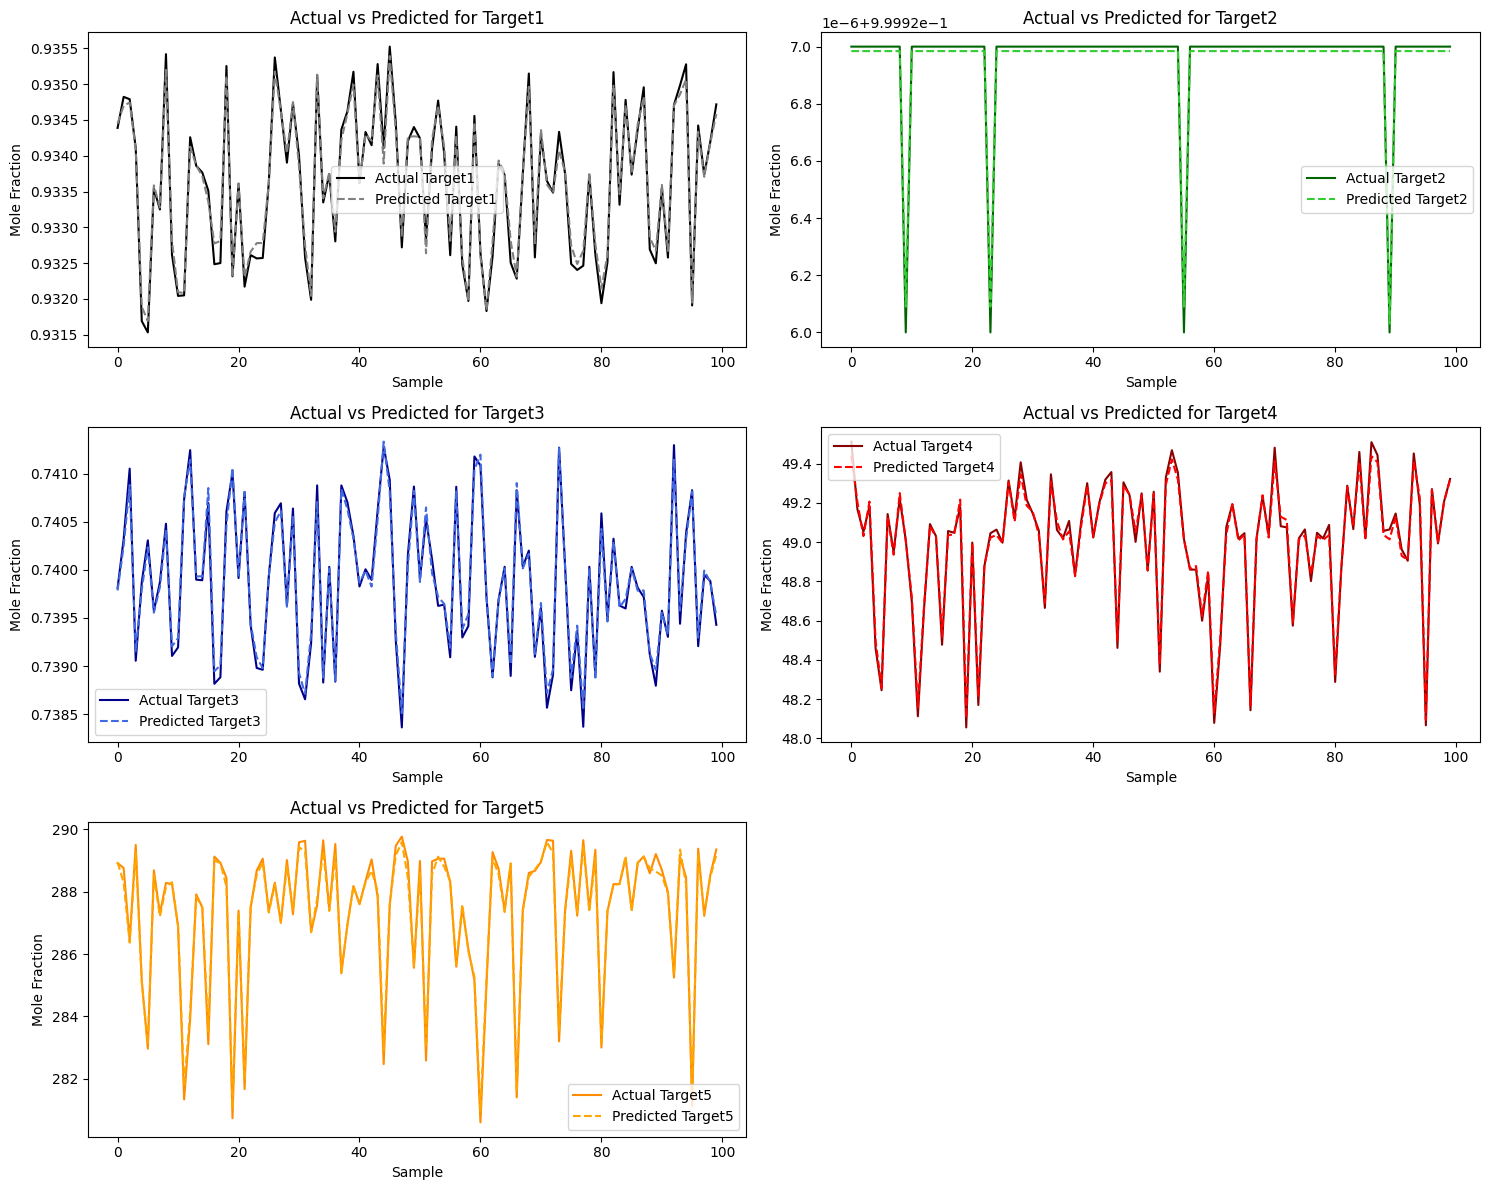

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# لیست اسامی تارگت‌ها
targets = ['Target1', 'Target2', 'Target3', 'Target4', 'Target5']

# ساخت DataFrame با استفاده از تارگت‌ها
data = {}
for i, label in enumerate(targets):
    data[f'Actual {label}'] = y_test_original[:, i]
    data[f'Predicted {label}'] = y_pred_original[:, i]

results = pd.DataFrame(data)

# انتخاب 100 نمونه اول
subset = results.iloc[:100]

# رنگ‌ها برای نمودارها
actual_colors = ['black', 'darkgreen', 'darkblue', 'darkred', 'darkorange']
predicted_colors = ['gray', 'limegreen', 'royalblue', 'red', 'orange']

# رسم نمودار برای هر تارگت
plt.figure(figsize=(15, 12))
for i, target in enumerate(targets):
    plt.subplot(3, 2, i + 1)
    if f'Actual {target}' in subset.columns and f'Predicted {target}' in subset.columns:
        plt.plot(subset[f'Actual {target}'], label=f'Actual {target}', color=actual_colors[i])
        plt.plot(subset[f'Predicted {target}'], linestyle='--', label=f'Predicted {target}', color=predicted_colors[i])
        plt.xlabel('Sample')
        plt.ylabel('Mole Fraction')
        plt.title(f'Actual vs Predicted for {target}')
        plt.legend()
    else:
        plt.text(0.5, 0.5, f'{target} not found', ha='center')
plt.tight_layout()
plt.show()

In [22]:
def percentage_within_tolerance(y_true, y_pred, tolerance):
    diff = np.abs(y_true - y_pred)
    within_tol = np.sum(diff <= tolerance)
    return (within_tol / len(y_true)) * 100

In [23]:
labels = ['Target1', 'Target2', 'Target3', 'Target4', 'Target5']  # به ترتیب: 3 تا غلظت، 2 تا دبی

# تولرانس‌های جداگانه برای هر خروجی
tolerances_per_output = {
    'Target1': [0.001, 0.0001, 0.00005],  # غلظت
    'Target2': [0.001, 0.0001, 0.00005],  # غلظت
    'Target3': [0.001, 0.0001, 0.00005],  # غلظت
    'Target4': [0.02, 0.05, 0.1],             # دبی
    'Target5': [0.02, 0.05, 0.1]              # دبی
}
all_results = {label: [] for label in labels}

In [24]:
# بررسی دقت بر اساس تولرانس‌های اختصاصی هر خروجی
for label_index, label in enumerate(labels):
    print(f"\n--- Accuracy for {label} ---")
    for tol in tolerances_per_output[label]:
        acc = percentage_within_tolerance(y_test_original[:, label_index], y_pred_original[:, label_index], tolerance=tol)
        all_results[label].append(acc)
        print(f"Tolerance ±{tol}: {acc:.2f}%")


--- Accuracy for Target1 ---
Tolerance ±0.001: 100.00%
Tolerance ±0.0001: 60.82%
Tolerance ±5e-05: 43.11%

--- Accuracy for Target2 ---
Tolerance ±0.001: 100.00%
Tolerance ±0.0001: 100.00%
Tolerance ±5e-05: 100.00%

--- Accuracy for Target3 ---
Tolerance ±0.001: 100.00%
Tolerance ±0.0001: 76.57%
Tolerance ±5e-05: 50.98%

--- Accuracy for Target4 ---
Tolerance ±0.02: 54.34%
Tolerance ±0.05: 84.79%
Tolerance ±0.1: 99.60%

--- Accuracy for Target5 ---
Tolerance ±0.02: 13.37%
Tolerance ±0.05: 29.74%
Tolerance ±0.1: 48.93%


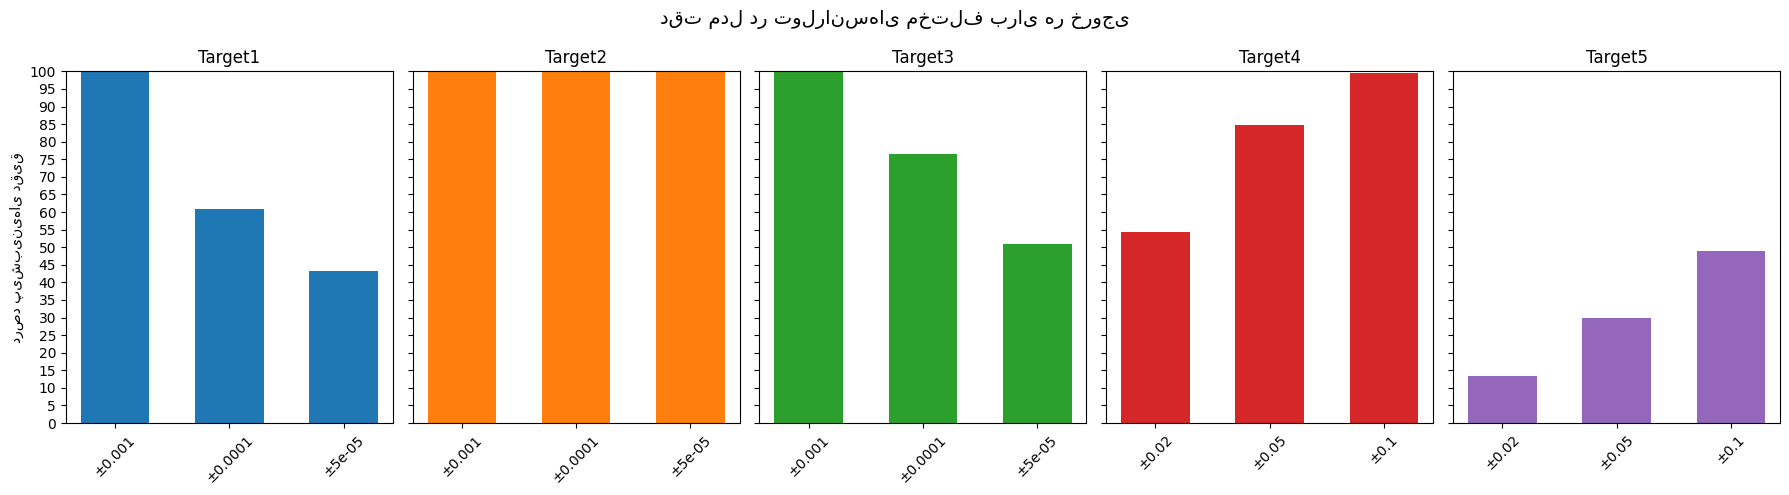

In [25]:
import matplotlib.pyplot as plt
import numpy as np

labels = ['Target1', 'Target2', 'Target3', 'Target4', 'Target5']

# فرض: all_results دیکشنری با مقادیر لیستی از دقت‌ها
# مثل {'Target1': [...], 'Target2': [...], ...}

fig, axs = plt.subplots(1, len(labels), figsize=(18, 5), sharey=True)

for i, label in enumerate(labels):
    accs = all_results[label]
    tols = tolerances_per_output[label]
    
    x = np.arange(len(tols))
    axs[i].bar(x, accs, color=plt.cm.tab10(i), width=0.6)
    axs[i].set_xticks(x)
    axs[i].set_xticklabels([f'±{t}' for t in tols], rotation=45)
    axs[i].set_title(label)
    axs[i].set_ylim(0, 100)
    axs[i].set_yticks(np.arange(0, 101, 5))

axs[0].set_ylabel("درصد پیش‌بینی‌های دقیق")
fig.suptitle("دقت مدل در تولرانس‌های مختلف برای هر خروجی", fontsize=14)
plt.tight_layout()
plt.show()

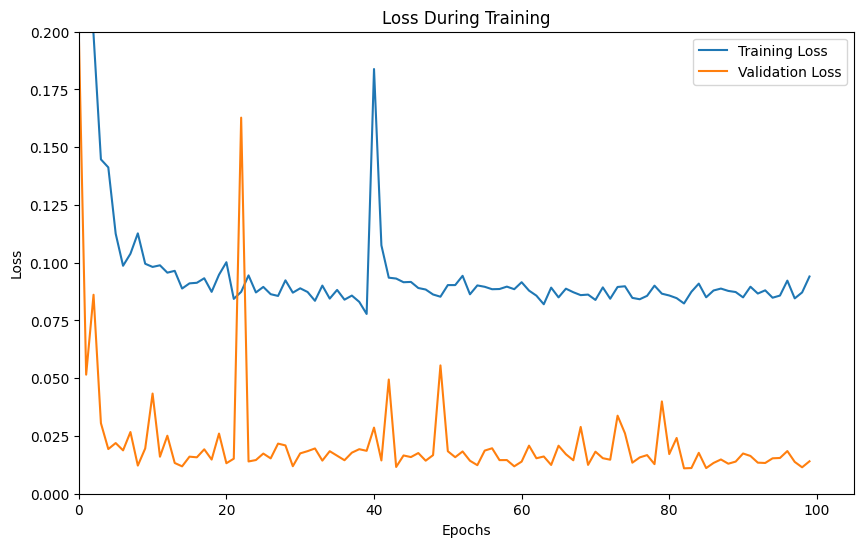

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss During Training')
plt.legend()
plt.xlim(0,105)
plt.ylim(0,0.2)
plt.show()